# Sentiment: Baseline vs Fine-Tuned Transformer

Goal: compare a classic TF-IDF + Logistic Regression baseline against a fine-tuned DistilBERT model on the same movie review sentiment data, and understand *why* one beats the other on specific examples.

## Step 1 — Load the data

Before any modeling, we need text paired with a label (positive/negative). We'll use a small subset of IMDB reviews so things run fast while we're still learning the pipeline.

In [1]:
from datasets import load_dataset

# Load the full IMDB dataset (50k train / 50k test, balanced pos/neg)
imdb = load_dataset("imdb")

# Take a small, class-balanced subset so training/experiments are fast
train_small = imdb["train"].shuffle(seed=42).select(range(2000))
test_small = imdb["test"].shuffle(seed=42).select(range(500))

train_small, test_small

(Dataset({
     features: ['text', 'label'],
     num_rows: 2000
 }),
 Dataset({
     features: ['text', 'label'],
     num_rows: 500
 }))

In [2]:
print(train_small[0])

{'text': 'There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier\'s plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer American series (!!!). Maybe it\'s the language, or the spirit, but I think this series is more English than American. By the way, the actors are really good and funny. The acting is not superficial at all...', 'label': 1}


## Step 2 — Look at the data before modeling

Two quick sanity checks: are positive/negative roughly balanced in our subset, and how long are these reviews? Both affect how we approach modeling later.

In [3]:
import pandas as pd

# Convert to a DataFrame just because it's easier to inspect/count with pandas
train_df = train_small.to_pandas()

# Count how many of each label we have (0 = negative, 1 = positive)
print("Class counts:\n", train_df["label"].value_counts())

# Review length in words, so we know roughly how long the text inputs are
train_df["num_words"] = train_df["text"].str.split().str.len()
print("\nReview length (words) stats:\n", train_df["num_words"].describe())

Class counts:
 label
1    1000
0    1000
Name: count, dtype: int64

Review length (words) stats:
 count    2000.00000
mean      228.43450
std       168.67367
min        12.00000
25%       127.00000
50%       172.00000
75%       268.25000
max      1005.00000
Name: num_words, dtype: float64


## Step 3 — Baseline: turn text into numbers (TF-IDF)

Models don't understand words directly — they need numbers. TF-IDF converts each review into a vector of numbers representing which words appear and how "important" they are.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

y_train = train_small["label"]
y_test = test_small["label"]

# max_features caps vocabulary size; stop_words drops common words like "the", "is"
vectorizer = TfidfVectorizer(max_features=10000, stop_words="english")

# fit_transform learns the vocabulary from train text AND converts it to vectors
X_train_tfidf = vectorizer.fit_transform(train_small["text"])

# transform (not fit_transform!) reuses the train vocabulary on test text
X_test_tfidf = vectorizer.transform(test_small["text"])

X_train_tfidf.shape, X_test_tfidf.shape

((2000, 10000), (500, 10000))

## Step 4 — Baseline: train Logistic Regression

Now that reviews are numeric vectors, we train a Logistic Regression classifier to map those vectors to positive/negative.

In [5]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_tfidf, y_train)

# Predicted labels for the test set (never seen during training)
baseline_preds = baseline_model.predict(X_test_tfidf)
baseline_preds[:20]

array([1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1])

## Step 5 — Evaluate the baseline properly

Accuracy alone can hide problems (e.g. a model that's great at one class and bad at the other). We use precision, recall, F1, and a confusion matrix to see the full picture.

              precision    recall  f1-score   support

    negative       0.84      0.81      0.83       254
    positive       0.82      0.85      0.83       246

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



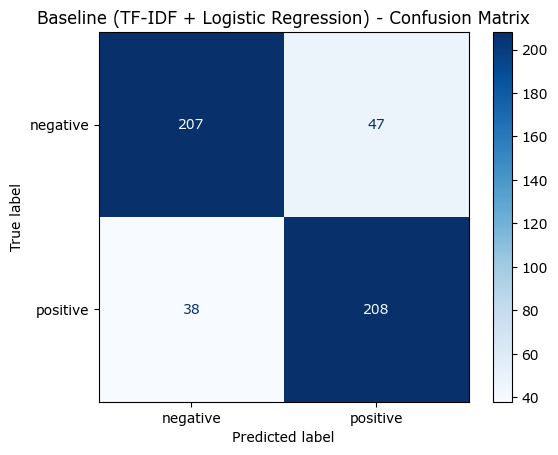

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, baseline_preds, target_names=["negative", "positive"]))

cm = confusion_matrix(y_test, baseline_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot(cmap="Blues")
plt.title("Baseline (TF-IDF + Logistic Regression) - Confusion Matrix")
plt.show()